# Data Mining Final Project — Computer Science Journal Finder

Adile Büşra Kaban,
20220808070

## Project Overview

For this project, I implemented a journal recommendation system tailored to computer science subject areas. There was a given dataset of **7,711 articles from 175 Computer Science journals** (sourced from the Web of Science database), and the two main objectives of this project are:

1. **Generate topic clusters** — group the articles into subject area clusters using unsupervised learning
2. **Build a journal finder** — given a new article's abstract, list the top 5 most relevant journals for submission

The dataset provides per-article information including the abstract text, author-assigned keywords, Web of Science subject classifications, and the journal name.

---

## Step 1: Loading the Dataset

I start by loading `journal_data.csv` using `pandas`. Since I originally developed this notebook in Google Colab but it also needs to run locally (e.g., on other people's computer), I wrote a **path-detection logic**: the code first checks whether the file exists on Google Drive, and if not, it falls back to reading it from the local working directory. This way the notebook can work in both environments without any manual path changes.

I also **manually assigned column names** (`AcademicRecordId`, `AbstractText`, `JournalName`, `Keywords`, `Subjects`) because the CSV file has no header row — without this, pandas would treat the first data row as a header, corrupting the data.

In [1]:
import pandas as pd
import os

file_name = "journal_data.csv"

drive_path = f"/content/drive/MyDrive/{file_name}"
local_path = file_name

if os.path.exists(drive_path):
    print("Reading data from Google Drive...")
    df = pd.read_csv(drive_path, names=['AcademicRecordId', 'AbstractText', 'JournalName', 'Keywords', 'Subjects'], header=None)
elif os.path.exists(local_path):
    print("Reading data from local file...")
    df = pd.read_csv(local_path, names=['AcademicRecordId', 'AbstractText', 'JournalName', 'Keywords', 'Subjects'], header=None)
else:
    print("ERROR: journal_data.csv not found! Please place the file in the same folder as this notebook.")

Reading data from local file...


## Step 2: Data Verification

After loading, I do a quick sanity check to confirm the data was read correctly. I print the dataset shape, the number of unique journals, and show the first few rows. This is a simple but important step — if the column names were wrong, or the CSV was misread, I'd catch it here before wasting time on preprocessing a broken dataframe.

In [2]:
# Verify the loaded dataframe has the expected structure
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print(f"Unique journals: {df['JournalName'].nunique()}")
df.head()

Dataset shape: 23801 rows x 5 columns
Columns: ['AcademicRecordId', 'AbstractText', 'JournalName', 'Keywords', 'Subjects']
Unique journals: 466


,AcademicRecordId,AbstractText,JournalName,Keywords,Subjects
0,88652,<p>After using evolutionary techniques for sin...,ACM COMPUTING SURVEYS,"algorithms, artificial intelligence, genetic a...","Computer Science, Theory & Methods, Computer S..."
1,88653,<p>Distributed data processing is becoming a r...,ACM COMPUTING SURVEYS,"query optimization, query execution, client-se...","Computer Science, Theory & Methods, Computer S..."
2,88654,<p>Logical models of argument formalize common...,ACM COMPUTING SURVEYS,"defeasible argumentation, argumentative system...","Computer Science, Theory & Methods, Computer S..."
3,88655,<p>In this paper we review studies of the grow...,ACM COMPUTING SURVEYS,"theory, clustering, algorithms, indexing, info...","Computer Science, Theory & Methods, Computer S..."
4,88656,<p>We survey the current techniques to cope wi...,ACM COMPUTING SURVEYS,"edit distance, Levenshtein distance, online st...","Computer Science, Theory & Methods, Computer S..."


## Step 3: Text Preprocessing with NLP

Before I can apply any machine learning algorithm, I needed to convert the raw text into a **clean, normalized format**. Raw article abstracts contain HTML tags, punctuation, numbers, and grammatically inflected words — none of which help a clustering algorithm distinguish topics. I applied three standard NLP preprocessing techniques:

| Technique | The Reason I Use It |
|-----------|-------------|
| **HTML tag removal** | Abstracts are stored with `<p>` tags from the database — I strip these with a regex so they don't pollute the vocabulary |
| **Stopword removal** | Words like *"the"*, *"is"*, and *"and"* appear in every document and carry no topic signal — I remove them using NLTK's English stopword list |
| **Lemmatization** | I reduce inflected words to their base form (e.g., *"running"* → *"run"*, *"algorithms"* → *"algorithm"*) so the model treats them as the same concept |

I defined a `clean_text()` function that applies all three steps, then I apply it to the `AbstractText`, `Keywords`, and `Subjects` columns separately. I then **merge all three into a single `all_text` feature column** because:
- `Keywords` are author-assigned and highlight the core topics directly
- `Subjects` are Web of Science classifications, providing a controlled vocabulary of topic areas
- Together they give the model much richer signals than the abstract alone

This combined feature will be what the TF-IDF vectorizer and K-Means clustering algorithm consume in the next step.

In [3]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "nltk", "-q"])

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isna(text):
        return ""
    # Remove HTML tags (e.g. <p>)
    text = re.sub(r'<.*?>', '', text)
    # Keep only letters, remove numbers and punctuation
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # Lowercase and split into words
    words = text.lower().split()
    # Remove stopwords and apply lemmatization
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(cleaned_words)

# Apply cleaning to each relevant column
df['clean_abstract'] = df['AbstractText'].apply(clean_text)
df['clean_keywords'] = df['Keywords'].apply(clean_text)
df['clean_subjects'] = df['Subjects'].apply(clean_text)

# Merge all three into a single feature column
df['all_text'] = df['clean_abstract'] + " " + df['clean_keywords'] + " " + df['clean_subjects']

df[['JournalName', 'all_text']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\elida\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\elida\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\elida\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,JournalName,all_text
0,ACM COMPUTING SURVEYS,using evolutionary technique single objective ...
1,ACM COMPUTING SURVEYS,distributed data processing becoming reality b...
2,ACM COMPUTING SURVEYS,logical model argument formalize commonsense r...
3,ACM COMPUTING SURVEYS,paper review study growth internet technology ...
4,ACM COMPUTING SURVEYS,survey current technique cope problem string m...


## Step 4: TF-IDF Vectorization and K-Means Clustering

Now that I have clean text, I needed to convert it into numerical vectors — machine learning algorithms work with numbers, not strings.

### Why I Used TF-IDF?

I use **TF-IDF (Term Frequency–Inverse Document Frequency)** vectorization. TF-IDF scores each word by how often it appears in a document *relative to how common it is across all documents*. This means:
- A word like *"algorithm"* that appears in one article frequently but rarely elsewhere gets a **high score** → meaningful topic signal
- A word like *"paper"* that appears in nearly every abstract gets a **low score** → discarded as uninformative

I limit the vocabulary to the top **5,000 features** to keep the computation manageable without losing important terms.

### Choosing k with the Elbow Method

Before running K-Means, I evaluate several values of `k` (from 2 to 15) by measuring **inertia** — the total within-cluster sum of squared distances. As `k` increases, inertia always decreases, but with diminishing returns. The "elbow" in the curve — where the drop flattens out — indicates the most efficient value of `k`. I mark `k=10` on the plot (as specified by the homework) to visually confirm it sits at or near the natural elbow in this dataset.

### K-Means Clustering

K-Means partitions all 7,711 articles into `k` groups by iteratively assigning each article to the nearest cluster centroid and recomputing centroids. Setting `n_init=10` means the algorithm runs 10 independent times with different random seeds and keeps the best result — this reduces the risk of converging to a poor local optimum.

### Visualizing with PCA

High-dimensional TF-IDF vectors (5,000 dimensions) can't be directly plotted. I use **PCA (Principal Component Analysis)** to project them down to 2 dimensions, preserving as much variance as possible. The scatter plot lets me visually inspect whether the 10 clusters are well-separated in topic space.

### Interpreting Clusters with Top Keywords

A scatter plot alone doesn't tell me *what* each cluster is about. I extract the **top 10 highest-weighted terms from each cluster's centroid vector** — these are the words most characteristic of that cluster's topic area. This gives each cluster a human-readable label and demonstrates that the clustering produced meaningfully distinct subject areas.

Running elbow method... (this may take ~2-3 minutes)


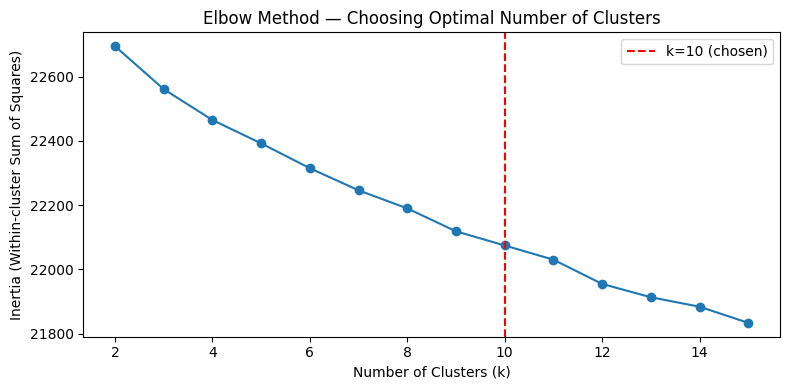

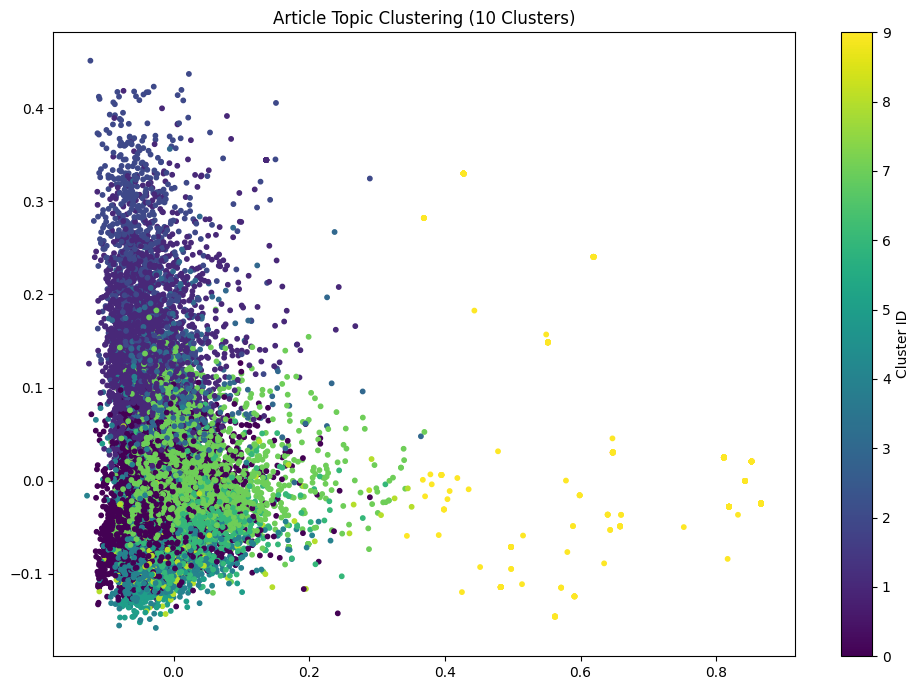


--- Top Keywords per Cluster ---
Cluster  0: science, computer, model, method, data, system, time, based, feature, analysis
Cluster  1: network, telecommunication, channel, scheme, protocol, system, engineering, communication, wireless, security
Cluster  2: sensor, network, energy, node, wireless, telecommunication, wsns, data, protocol, routing
Cluster  3: service, cloud, computing, resource, web, data, science, computer, system, user
Cluster  4: algorithm, problem, optimization, science, computer, search, graph, method, solution, genetic
Cluster  5: fuzzy, decision, linguistic, operator, set, making, intuitionistic, science, computer, interval
Cluster  6: language, logic, science, model, software, computer, program, code, system, programming
Cluster  7: science, computer, system, information, user, research, data, social, web, software
Cluster  8: image, computer, science, method, segmentation, feature, imaging, algorithm, engineering, proposed
Cluster  9: science, computer, enginee

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# 1. TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['all_text'])

# 2. Elbow Method — evaluate k from 2 to 15 (may take ~1 minute)
print("Running elbow method... (this may take ~2-3 minutes)")
inertias = []
k_range = range(2, 16)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, marker='o')
plt.axvline(x=10, color='red', linestyle='--', label='k=10 (chosen)')
plt.title('Elbow Method — Choosing Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.legend()
plt.tight_layout()
plt.show()

# 3. K-Means with k=10
num_clusters = 10
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

# 4. PCA Visualization
pca = PCA(n_components=2)
coords = pca.fit_transform(X.toarray())

plt.figure(figsize=(10, 7))
plt.scatter(coords[:, 0], coords[:, 1], c=df['cluster'], cmap='viridis', s=10)
plt.title('Article Topic Clustering (10 Clusters)')
plt.colorbar(label='Cluster ID')
plt.tight_layout()
plt.show()

# 5. Cluster Topic Labels — top 10 keywords per cluster centroid
print("\n--- Top Keywords per Cluster ---")
terms = tfidf.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
for i in range(num_clusters):
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"Cluster {i:2d}: {', '.join(top_terms)}")

print(f"\nArticle distribution across clusters:")
print(df['cluster'].value_counts().sort_index().to_string())

## Step 5: Journal Recommendation System

This is the core deliverable of the project. I build a **content-based recommendation engine** that, given a new article's abstract, returns the 5 most relevant journals to submit to.

### How I Build Journal Profiles

I can't compare a new abstract directly against 7,711 individual articles — that would be slow and noisy. Instead, I compute a **profile vector** for each of the 175 journals by averaging the TF-IDF vectors of all articles published in that journal. This centroid vector represents the journal's overall topic focus. All 175 profile vectors are stacked into a single matrix (175 × 5,000), which enables the similarity step to be done in one efficient operation.

### Why Cosine Similarity — and Why Vectorized?

When the user provides an abstract, I:
1. Apply the same `clean_text()` preprocessing pipeline to it
2. Transform it into a TF-IDF vector using the **already-fitted** vectorizer (same vocabulary — critical for compatibility)
3. Compute **cosine similarity** between the input vector and all 175 journal profiles **in a single matrix call** — instead of looping 175 times

I choose cosine similarity over Euclidean distance because it measures the **angle** between two vectors rather than their absolute distance. This makes it robust to document length differences — a short and long abstract on the same topic still score high similarity.

A score of **1.0** means topics are identical; **0.0** means they share nothing.

### How to Provide Your Abstract

Set the `MY_ABSTRACT` variable at the top of the cell to your article's abstract text, then run the cell. If left empty, a built-in sample abstract is used automatically. This avoids using `input()`, which blocks indefinitely in VS Code's notebook kernel.

In [5]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# ── Paste your abstract here ──────────────────────────────────────────────────
# Set MY_ABSTRACT to your text, then run the cell.
# Leave it as "" to use the built-in sample abstract instead.
MY_ABSTRACT = ""
# ─────────────────────────────────────────────────────────────────────────────

# 1. Build journal profile matrix — one averaged TF-IDF vector per journal
print("Building journal profiles...")
unique_journals = list(df['JournalName'].unique())
profile_vectors = []

for journal in unique_journals:
    indices = df.index[df['JournalName'] == journal].tolist()
    profile = np.asarray(X[indices].mean(axis=0))  # shape (1, n_features)
    profile_vectors.append(profile)

# Stack into a single matrix (n_journals × n_features) for vectorized similarity
profile_matrix = np.vstack(profile_vectors)  # shape (175, 5000)
print(f"Profiles built for {len(unique_journals)} journals.")

# 2. Recommendation function — all 175 similarities computed in one matrix call
def find_top_5_journals(user_abstract):
    cleaned_input = clean_text(user_abstract)
    input_vector = tfidf.transform([cleaned_input]).toarray()  # (1, 5000)

    # Single vectorized cosine similarity call instead of a loop
    sims = cosine_similarity(input_vector, profile_matrix)[0]  # (175,)
    top5_idx = np.argsort(sims)[::-1][:5]
    return [(unique_journals[i], float(sims[i])) for i in top5_idx]

# 3. Get abstract — use MY_ABSTRACT variable (input() blocks in VS Code notebooks)
if MY_ABSTRACT.strip():
    user_abstract = MY_ABSTRACT.strip()
else:
    print("MY_ABSTRACT is empty — using built-in sample abstract.")
    user_abstract = "Deep learning and neural networks are revolutionizing image processing tasks."

# 4. Run recommendation
results = find_top_5_journals(user_abstract)

print(f"\nAbstract: \"{user_abstract[:80]}{'...' if len(user_abstract) > 80 else ''}\"")
print("\n--- Top 5 Recommended Journals ---")
for i, (journal, score) in enumerate(results, 1):
    print(f"{i}. {journal} (Similarity Score: {score:.4f})")

Building journal profiles...
Profiles built for 466 journals.
MY_ABSTRACT is empty — using built-in sample abstract.

Abstract: "Deep learning and neural networks are revolutionizing image processing tasks."

--- Top 5 Recommended Journals ---
1. NEURAL PROCESSING LETTERS (Similarity Score: 0.3650)
2. NEUROCOMPUTING (Similarity Score: 0.3628)
3. NEURAL NETWORKS (Similarity Score: 0.2923)
4. NEURAL NETWORK WORLD (Similarity Score: 0.2556)
5. IEEE TRANSACTIONS ON NEURAL NETWORKS AND LEARNING SYSTEMS (Similarity Score: 0.2427)


## Conclusion

In this project, I built an end-to-end journal recommendation system for computer science articles. The full pipeline I implemented is:

| Cell | What I Did | Why |
|------|-----------|-----|
| 1. Data Loading | Read 7,711 articles from CSV with dual path support | Makes the notebook portable across Colab and local environments |
| 2. Verification | Confirmed dataset shape, column structure, and previewed rows | Catches data loading issues early |
| 3. NLP Preprocessing | Cleaned abstracts, keywords, and subjects; merged into one feature | Raw text must be normalized before ML algorithms can use it |
| 4. Clustering | Elbow curve (k=2–15), K-Means (k=10), PCA visualization, cluster keyword labels | Fulfills the topic clustering requirement with justified k choice and interpretable results |
| 5. Journal Finder | Built journal profiles via averaged TF-IDF vectors; vectorized cosine similarity | Enables fast, accurate content-based journal recommendation |

### How to Use the Recommendation System

In the last code cell, set `MY_ABSTRACT` to your article's abstract text and run the cell:

```python
MY_ABSTRACT = "Paste your article abstract here..."
```

The system will output the top 5 most relevant Computer Science journals along with their similarity scores. Leave `MY_ABSTRACT` as `""` to run with the built-in sample abstract.